# Problem 3.3 — Python translation

This notebook translates the Mathematica calculations into Python using NumPy, SciPy, Matplotlib, and optional `ipywidgets` controls.

It contains:

1. the RF Hamiltonian and its phase-space contours;
2. the exact pendulum solution in terms of Jacobi elliptic functions;
3. a unified treatment of libration, rotation, the separatrix, and the fixed points;
4. static and interactive plots; and
5. numerical checks of the initial conditions and energy conservation.

## Imports

The mathematical notation below uses the elliptic **modulus** $k$. SciPy's elliptic-function routines accept the parameter $m=k^2$, so every SciPy call passes `k**2` explicitly.

In [1]:
from dataclasses import dataclass
from typing import Callable

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipj, ellipk, ellipkinc

try:
    from ipywidgets import interact, FloatSlider, IntSlider
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("Optional interactive controls require ipywidgets: %pip install ipywidgets")

# plt.style.use("seaborn-v0_8-whitegrid")
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

## 1. RF Hamiltonian

The Mathematica definition is

$$
H(p_\phi,\phi;\psi_s,\Omega)
=\frac{p_\phi^2}{2}
+\frac{\Omega^2}{\cos\psi_s}
\left[\cos(\psi_s+\phi)-\cos\psi_s+\phi\sin\psi_s\right].
$$

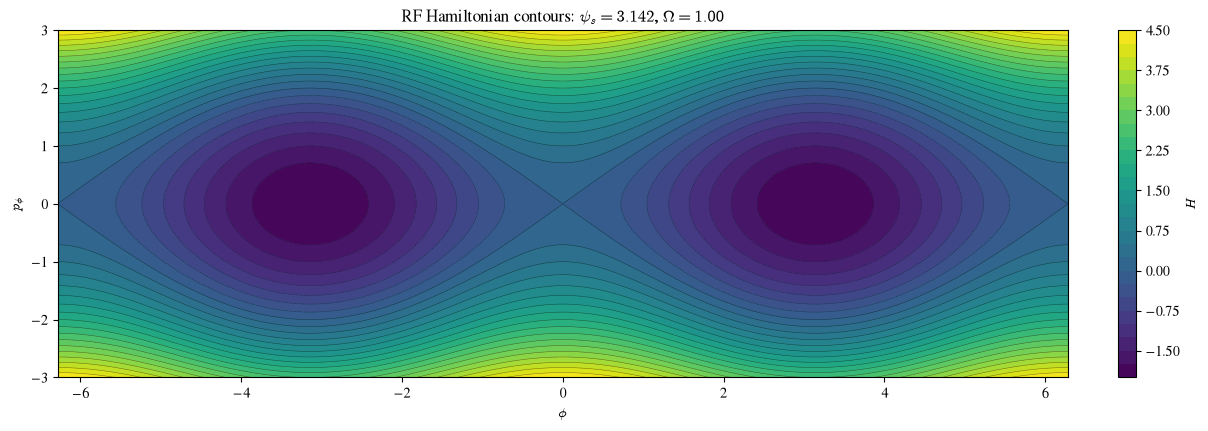

In [2]:
def rf_hamiltonian(p_phi, phi, psi_s, omega=1.0):
    """RF Hamiltonian from the original Mathematica notebook."""
    return (
        0.5 * np.asarray(p_phi) ** 2
        + omega**2
        / np.cos(psi_s)
        * (
            np.cos(psi_s + np.asarray(phi))
            - np.cos(psi_s)
            + np.asarray(phi) * np.sin(psi_s)
        )
    )


def plot_rf_hamiltonian(psi_s=np.pi, omega=1.0, levels=30):
    """Plot filled phase-space contours of the RF Hamiltonian."""
    phi = np.linspace(-2 * np.pi, 2 * np.pi, 500)
    p_phi = np.linspace(-3.0, 3.0, 260)
    PHI, P_PHI = np.meshgrid(phi, p_phi)
    H = rf_hamiltonian(P_PHI, PHI, psi_s, omega)

    fig, ax = plt.subplots(figsize=(12, 4.2), constrained_layout=True)
    filled = ax.contourf(PHI, P_PHI, H, levels=levels, cmap="viridis")
    ax.contour(PHI, P_PHI, H, levels=levels, colors="black", linewidths=0.35, alpha=0.55)
    fig.colorbar(filled, ax=ax, label=r"$H$")
    ax.set(
        xlabel=r"$\phi$",
        ylabel=r"$p_\phi$",
        title=rf"RF Hamiltonian contours: $\psi_s={psi_s:.3f}$, $\Omega={omega:.2f}$",
        xlim=(-2 * np.pi, 2 * np.pi),
        ylim=(-3, 3),
    )
    return fig, ax


plot_rf_hamiltonian(psi_s=np.pi, omega=1.0)
plt.show()

In [3]:
# Mathematica Manipulate translated to an optional Jupyter widget.
if WIDGETS_AVAILABLE:
    def explore_rf_hamiltonian(psi_s):
        plot_rf_hamiltonian(psi_s=psi_s, omega=1.0)
        plt.show()

    interact(
        explore_rf_hamiltonian,
        psi_s=FloatSlider(
            value=np.pi,
            min=np.pi / 2 + 0.05,
            max=3 * np.pi / 2 - 0.05,
            step=0.02,
            description=r"psi_s",
            continuous_update=False,
        ),
    )
else:
    print("Skipping the RF widget because ipywidgets is not installed.")

interactive(children=(FloatSlider(value=3.141592653589793, continuous_update=False, description='psi_s', max=4…

## 2. Exact normalized-pendulum solution

The normalized Hamiltonian is

$$
E=\frac{P^2}{2}-\cos\theta,
$$

and Hamilton's equations are $\dot\theta=P$ and $\dot P=-\sin\theta$.

For bounded motion, $-1<E<1$, define

$$
k=\sqrt{\frac{1+E}{2}}, \qquad
T=4K(k),
$$

where $K(k)$ is the complete elliptic integral of the first kind. The solution is

$$
\theta(\tau)=2\sin^{-1}\!\left[k\,\operatorname{sn}(z_0+\tau,k)\right],
\qquad
P(\tau)=2k\,\operatorname{cn}(z_0+\tau,k).
$$

For rotational motion, $E>1$, the reciprocal modulus $k_r=1/\kappa<1$ is used, with $\kappa=\sqrt{(E+1)/2}$. The code also evaluates the $E=1$ separatrix analytically.

In [4]:
@dataclass(frozen=True)
class PendulumSolution:
    motion: str
    energy: float
    modulus: float
    period: float
    theta: Callable[[np.ndarray], np.ndarray]
    momentum: Callable[[np.ndarray], np.ndarray]


def pendulum_energy(theta, momentum):
    """E = P^2/2 - cos(theta)."""
    return 0.5 * np.asarray(momentum) ** 2 - np.cos(np.asarray(theta))


def wrap_angle(theta):
    """Map an angle to [-pi, pi)."""
    return (np.asarray(theta) + np.pi) % (2 * np.pi) - np.pi


def pendulum_solution(theta0, p0, tau0=0.0, tolerance=1e-10):
    """
    Return the exact trajectory for arbitrary initial conditions.

    The returned modulus is k for libration and the reciprocal modulus
    k_r = 1/kappa for rotation. SciPy receives m = k**2 internally.
    """
    theta0 = float(theta0)
    p0 = float(p0)
    tau0 = float(tau0)

    energy_value = float(pendulum_energy(theta0, p0))
    theta_wrapped = float(wrap_angle(theta0))
    theta_shift = theta0 - theta_wrapped

    # Stable fixed point. The reported 2*pi is the limiting small-amplitude period.
    if abs(energy_value + 1.0) <= tolerance:
        return PendulumSolution(
            motion="Stable fixed point",
            energy=energy_value,
            modulus=0.0,
            period=2 * np.pi,
            theta=lambda tau: np.zeros_like(np.asarray(tau, dtype=float)) + theta0,
            momentum=lambda tau: np.zeros_like(np.asarray(tau, dtype=float)),
        )

    # Libration: -1 < E < 1.
    if energy_value < 1.0 - tolerance:
        k = np.sqrt((1.0 + energy_value) / 2.0)
        m = k**2

        sn0 = np.clip(np.sin(theta_wrapped / 2.0) / k, -1.0, 1.0)
        cn0 = np.clip(p0 / (2.0 * k), -1.0, 1.0)
        amplitude0 = np.arctan2(sn0, cn0)
        z0 = ellipkinc(amplitude0, m)

        def theta(tau):
            z = z0 + np.asarray(tau, dtype=float) - tau0
            sn, _, _, _ = ellipj(z, m)
            return theta_shift + 2.0 * np.arcsin(np.clip(k * sn, -1.0, 1.0))

        def momentum(tau):
            z = z0 + np.asarray(tau, dtype=float) - tau0
            _, cn, _, _ = ellipj(z, m)
            return 2.0 * k * cn

        return PendulumSolution(
            motion="Libration",
            energy=energy_value,
            modulus=k,
            period=4.0 * ellipk(m),
            theta=theta,
            momentum=momentum,
        )

    # Rotation: E > 1.
    if energy_value > 1.0 + tolerance:
        direction = 1.0 if p0 >= 0.0 else -1.0
        kappa = np.sqrt((energy_value + 1.0) / 2.0)
        k_reciprocal = 1.0 / kappa
        m = k_reciprocal**2
        z0 = ellipkinc(theta_wrapped / 2.0, m)

        def theta(tau):
            z = z0 + direction * kappa * (np.asarray(tau, dtype=float) - tau0)
            _, _, _, amplitude = ellipj(z, m)
            return theta_shift + 2.0 * amplitude

        def momentum(tau):
            z = z0 + direction * kappa * (np.asarray(tau, dtype=float) - tau0)
            _, _, dn, _ = ellipj(z, m)
            return 2.0 * direction * kappa * dn

        return PendulumSolution(
            motion="Rotation",
            energy=energy_value,
            modulus=k_reciprocal,
            period=2.0 * ellipk(m) / kappa,
            theta=theta,
            momentum=momentum,
        )

    # Separatrix: E = 1.
    if abs(p0) < tolerance and abs(abs(theta_wrapped) - np.pi) < 1e-8:
        return PendulumSolution(
            motion="Unstable fixed point",
            energy=energy_value,
            modulus=1.0,
            period=np.inf,
            theta=lambda tau: np.zeros_like(np.asarray(tau, dtype=float)) + theta0,
            momentum=lambda tau: np.zeros_like(np.asarray(tau, dtype=float)),
        )

    direction = 1.0 if p0 >= 0.0 else -1.0
    crossing_time = tau0 - direction * np.log(np.tan((np.pi + theta_wrapped) / 4.0))

    def theta(tau):
        exponent = direction * (np.asarray(tau, dtype=float) - crossing_time)
        return theta_shift + 4.0 * np.arctan(np.exp(np.clip(exponent, -700, 700))) - np.pi

    def momentum(tau):
        return 2.0 * direction / np.cosh(np.asarray(tau, dtype=float) - crossing_time)

    return PendulumSolution(
        motion="Separatrix",
        energy=energy_value,
        modulus=1.0,
        period=np.inf,
        theta=theta,
        momentum=momentum,
    )

In [5]:
@dataclass(frozen=True)
class StationaryBucketParameters:
    """Constant parameters for the single-harmonic stationary bucket."""

    harmonic: int = 588
    eta0: float = 0.00871573
    beta_s: float = 0.9944081
    energy_s_eV: float = 8.8846823e+09
    voltage_V: float = 80e3
    f_rev_Hz: float = 89809.71157871
    charge_state: float = 1.0
    phi_s: float = np.pi
    phi_rf: float = np.pi
    blond_synchronous_time_s: float | None = None

    def __post_init__(self):
        if self.harmonic <= 0:
            raise ValueError("harmonic must be positive.")
        if self.eta0 <= 0:
            raise ValueError(
                "This notebook section assumes phi_s = pi and therefore eta0 > 0."
            )
        if not (0.0 < self.beta_s <= 1.0):
            raise ValueError("beta_s must satisfy 0 < beta_s <= 1.")
        if self.energy_s_eV <= 0.0:
            raise ValueError("energy_s_eV must be positive.")
        if self.voltage_V <= 0.0:
            raise ValueError("voltage_V must be positive.")
        if self.charge_state <= 0.0:
            raise ValueError("charge_state must be positive for this convention.")
        if self.f_rev_Hz <= 0.0:
            raise ValueError("f_rev_Hz must be positive.")
        if not np.isclose(np.cos(self.phi_s), -1.0, atol=1e-10):
            raise ValueError(
                "The exact normalized solution used here assumes phi_s = pi modulo 2*pi."
            )

    @property
    def qV_eV(self):
        """RF energy scale qV in eV for a charge state in elementary-charge units."""
        return self.charge_state * self.voltage_V

    @property
    def omega0_rad_s(self):
        return 2.0 * np.pi * self.f_rev_Hz

    @property
    def revolution_period_s(self):
        return 1.0 / self.f_rev_Hz

    @property
    def omega_rf_rad_s(self):
        return self.harmonic * self.omega0_rad_s

    @property
    def rf_period_s(self):
        return 2.0 * np.pi / self.omega_rf_rad_s

    @property
    def Q_s0(self):
        """Small-amplitude synchrotron tune."""
        return np.sqrt(
            self.harmonic
            * self.eta0
            * self.qV_eV
            / (2.0 * np.pi * self.beta_s**2 * self.energy_s_eV)
        )

    @property
    def omega_s0_rad_s(self):
        return self.Q_s0 * self.omega0_rad_s

    @property
    def energy_scale_eV(self):
        """Delta E = energy_scale_eV * P."""
        return np.sqrt(
            self.qV_eV
            * self.beta_s**2
            * self.energy_s_eV
            / (2.0 * np.pi * self.harmonic * self.eta0)
        )

    @property
    def synchronous_time_in_blond_s(self):
        """
        BLonD clock coordinate of the synchronous particle.

        If an explicit value was supplied, use it. Otherwise choose the bucket
        in [0, T_rf) satisfying omega_rf*dt_s + phi_rf = phi_s mod 2*pi.
        """
        if self.blond_synchronous_time_s is not None:
            return float(self.blond_synchronous_time_s)

        phase_difference = np.mod(self.phi_s - self.phi_rf, 2.0 * np.pi)
        return phase_difference / self.omega_rf_rad_s

    def turns_to_tau(self, turns, reference_turn=0.0):
        """Convert turn number to normalized pendulum time."""
        turns = np.asarray(turns, dtype=float)
        return 2.0 * np.pi * self.Q_s0 * (turns - reference_turn)

    def normalized_to_physical(self, theta, momentum):
        """
        Convert (theta, P) to time relative to the synchronous particle and dE.

        Returns
        -------
        delta_t_sync_s : ndarray
            Arrival-time difference relative to the synchronous particle [s].
        delta_E_eV : ndarray
            Energy difference relative to the synchronous particle [eV].
        """
        theta = np.asarray(theta, dtype=float)
        momentum = np.asarray(momentum, dtype=float)
        delta_t_sync_s = theta / self.omega_rf_rad_s
        delta_E_eV = self.energy_scale_eV * momentum
        return delta_t_sync_s, delta_E_eV

    def physical_to_normalized(self, delta_t_sync_s, delta_E_eV):
        """Convert physical coordinates relative to the synchronous particle."""
        delta_t_sync_s = np.asarray(delta_t_sync_s, dtype=float)
        delta_E_eV = np.asarray(delta_E_eV, dtype=float)
        theta = self.omega_rf_rad_s * delta_t_sync_s
        momentum = delta_E_eV / self.energy_scale_eV
        return theta, momentum

    def blond_dt_to_delta_t_sync(self, blond_dt_s, synchronous_time_s=None):
        """Convert BLonD Beam.dt to time relative to the synchronous particle."""
        if synchronous_time_s is None:
            synchronous_time_s = self.synchronous_time_in_blond_s
        return np.asarray(blond_dt_s, dtype=float) - synchronous_time_s

    def delta_t_sync_to_blond_dt(self, delta_t_sync_s, synchronous_time_s=None):
        """Convert synchronous-relative time back to BLonD Beam.dt."""
        if synchronous_time_s is None:
            synchronous_time_s = self.synchronous_time_in_blond_s
        return np.asarray(delta_t_sync_s, dtype=float) + synchronous_time_s

    def wrap_delta_t(self, delta_t_sync_s):
        """Wrap synchronous-relative time into one RF period."""
        delta_t_sync_s = np.asarray(delta_t_sync_s, dtype=float)
        return (
            delta_t_sync_s + 0.5 * self.rf_period_s
        ) % self.rf_period_s - 0.5 * self.rf_period_s


In [6]:
@dataclass(frozen=True)
class PhysicalTrajectory:
    """One particle sampled turn by turn."""

    model: str
    turns: np.ndarray
    tau: np.ndarray
    theta: np.ndarray
    momentum: np.ndarray
    delta_t_sync_s: np.ndarray
    delta_E_eV: np.ndarray
    normalized_energy: np.ndarray
    motion: str | None = None


def continuous_physical_trajectory(
    delta_t0_sync_s,
    delta_E0_eV,
    machine,
    turns=np.arange(0, 251),
):
    """Exact continuous Hamiltonian solution sampled at integer turns."""
    turns = np.asarray(turns, dtype=float)
    theta0, p0 = machine.physical_to_normalized(
        delta_t0_sync_s,
        delta_E0_eV,
    )
    theta0 = float(theta0)
    p0 = float(p0)

    solution = pendulum_solution(theta0, p0, tau0=0.0)
    tau = machine.turns_to_tau(turns, reference_turn=turns[0])
    theta = np.asarray(solution.theta(tau), dtype=float)
    momentum = np.asarray(solution.momentum(tau), dtype=float)
    delta_t_sync_s, delta_E_eV = machine.normalized_to_physical(
        theta,
        momentum,
    )

    return PhysicalTrajectory(
        model="Continuous exact Hamiltonian",
        turns=turns,
        tau=tau,
        theta=theta,
        momentum=momentum,
        delta_t_sync_s=delta_t_sync_s,
        delta_E_eV=delta_E_eV,
        normalized_energy=pendulum_energy(theta, momentum),
        motion=solution.motion,
    )

In [7]:
# Create a Gaussian grid of initial conditions for the pendulum and plot the resulting trajectories as a function of turns
# Center of the distribution (X_mean, Y_mean)
mean = [0, 0] 

# Covariance matrix defining the spread and relationship
# [[Variance_X, Covariance_XY], [Covariance_YX, Variance_Y]]
covariance = [[(np.pi / 12) ** 2, 0], 
              [0, 0.1]]  # Variance in theta and p_phi

# Generate 5,000 random coordinates
samples = np.random.multivariate_normal(mean, covariance, size=10000)

theta0_values, p0_values = samples[:, 0], samples[:, 1]

Text(0, 0.5, '$P_0$')

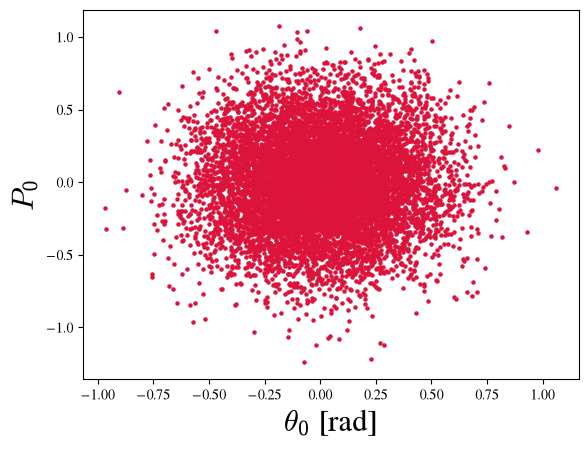

In [21]:
plt.scatter(theta0_values, p0_values, color="crimson", s=5)
plt.xlabel(r"$\theta_0$ [rad]", fontsize=22)
plt.ylabel(r"$P_0$", fontsize=22)

In [9]:
machine = StationaryBucketParameters(voltage_V=140e3)

print(f"Q_s0                   = {machine.Q_s0:.8g}")
print(f"Synchrotron period     = {1.0 / machine.Q_s0:.3f} turns")
print(f"RF period              = {machine.rf_period_s * 1e9:.6g} ns")
print(f"Energy scale           = {machine.energy_scale_eV / 1e6:.6g} MeV")

Q_s0                   = 0.0036051972
Synchrotron period     = 277.377 turns
RF period              = 18.9365 ns
Energy scale           = 6.18044 MeV


In [10]:
# Get solutions as for every initial condition and store the results
solutions = [pendulum_solution(theta0, p0) for theta0, p0 in zip(theta0_values, p0_values)]

# Define time grid to calculate the trajectories for each initial condition
turns = np.arange(0, 251*2, dtype=int)
tau_grid = 2.0 * np.pi * machine.Q_s0 * turns

# Calculate all solutions as function of time and store them in a list
solutions_over_tau = [(solution.theta(tau_grid), solution.momentum(tau_grid)) for solution in solutions]

solutions_over_turns = [
    machine.normalized_to_physical(theta, momentum)
    for theta, momentum in solutions_over_tau
]

Text(0, 0.5, '$p_\\phi$')

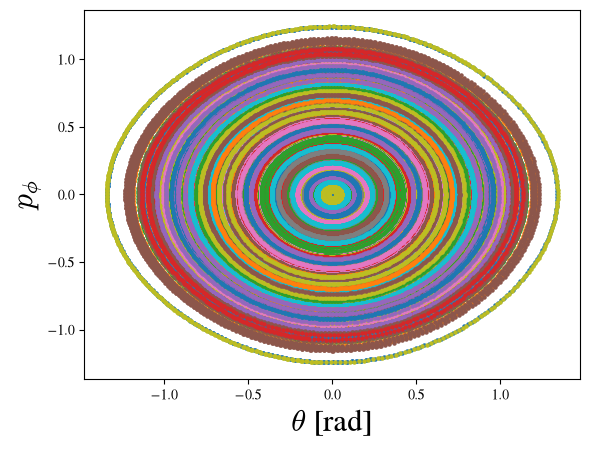

In [ ]:
for solution in solutions_over_tau:
    theta, momentum = solution
    plt.scatter(theta, momentum, s=5)  # Example of evaluating the theta and p_phi functions for each solution

plt.xlabel(r"$\theta$ [rad]", fontsize=22)
plt.ylabel(r"$P$", fontsize=22)

Text(0, 0.5, '$\\Delta E$ [MeV]')

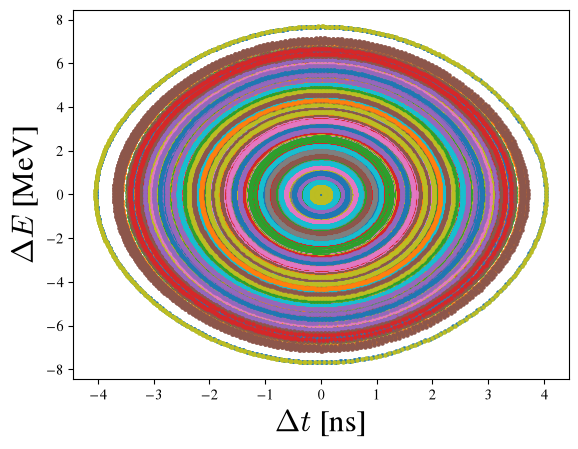

In [24]:
for solution in solutions_over_turns:
    delta_t_sync_s, delta_E_eV = solution
    plt.scatter(1e9*delta_t_sync_s, 1e-6*delta_E_eV, s=5)  # Example of evaluating the delta_t_sync and delta_E functions for each solution

plt.xlabel(r"$\Delta t$ [ns]", fontsize=22)
plt.ylabel(r"$\Delta E$ [MeV]", fontsize=22)

In [13]:
# Histogram the theta values at every time step to visualize the distribution of angles over time
# The bins should be set to cover the range of theta values, which is typically from -pi to pi for a pendulum.
# Save frequency distributions of theta at each time step
histograms_over_time = []
for i, tau in enumerate(tau_grid):
    theta_values_at_tau = [solution[0][i] for solution in solutions_over_tau]
    histogram, bin_edges = np.histogram(theta_values_at_tau, bins=100, range=(-np.pi, np.pi))
    histograms_over_time.append(histogram)

histograms_over_time = np.array(histograms_over_time)

In [14]:
# Histograms
bunch_bin_count=75, #18.9 nS / 0.25 nS = 75.6 rounded resolution
bunch_delta_energy_bin_range=[-40.0, 40.0] # MeV range
bunch_delta_time_bin_range = [-1e-8, 1e-8] # s range

print(f"bunch_bin_count = {bunch_bin_count}")
print(f"bunch_delta_energy_bin_range = {bunch_delta_energy_bin_range}")
print(f"bunch_delta_time_bin_range = {bunch_delta_time_bin_range}")

histograms_over_turns_deltat = []

for i, turn in enumerate(turns):
    delta_t_sync_values_at_turn = [solution[0][i] for solution in solutions_over_turns]
    histogram, bin_edges = np.histogram(delta_t_sync_values_at_turn, bins=1000, range=bunch_delta_time_bin_range)
    histograms_over_turns_deltat.append(histogram)


bunch_bin_count = (75,)
bunch_delta_energy_bin_range = [-40.0, 40.0]
bunch_delta_time_bin_range = [-1e-08, 1e-08]


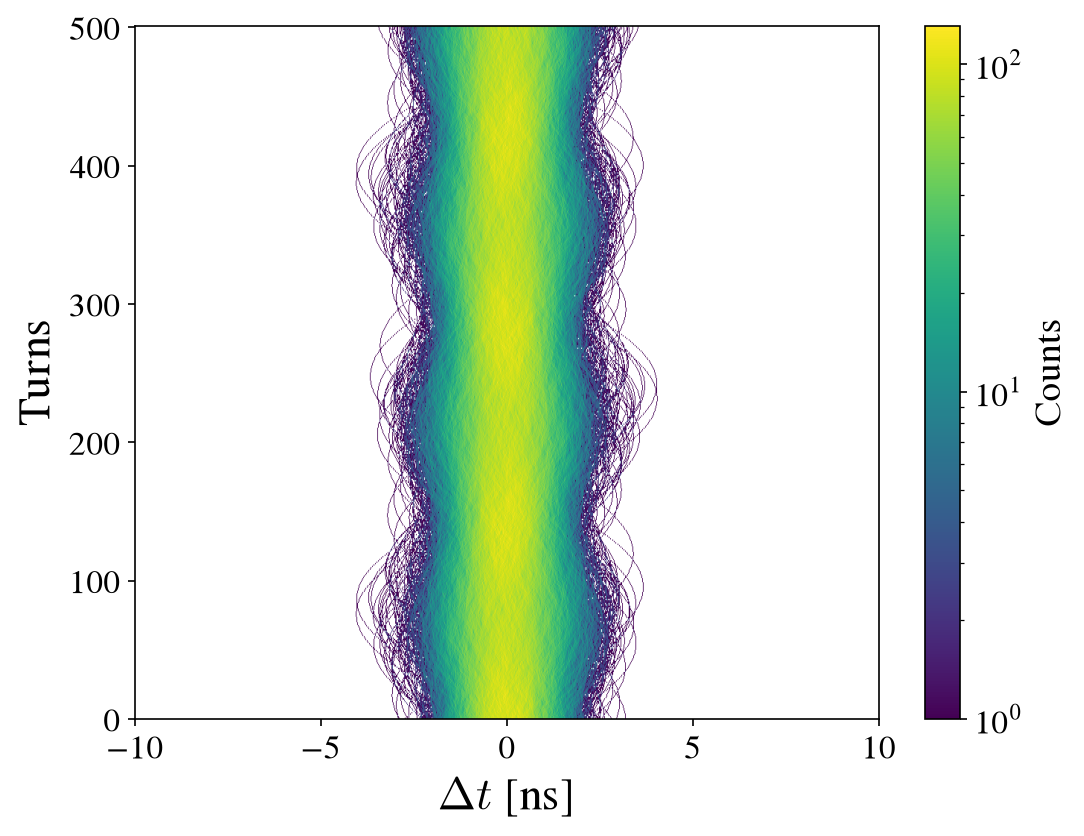

In [26]:
import matplotlib

fig,ax = plt.subplots(figsize=(8,6))
ax.imshow(histograms_over_turns_deltat, extent=[ 1e9*bunch_delta_time_bin_range[0], 1e9*bunch_delta_time_bin_range[1],turns[0], turns[-1],], 
           aspect='auto', origin='lower',cmap='viridis', norm=matplotlib.colors.LogNorm())

ax.set_xlabel(r"$\Delta t$ [ns]", fontsize=22)
ax.set_ylabel("Turns", fontsize=22)

ax.grid(False)
ax.tick_params(axis='both', which='major', labelsize=16)

# Create a colorbar with a logarithmic scale
cbar = fig.colorbar(ax.images[0], ax=ax, orientation='vertical')
cbar.set_label('Counts', fontsize=18)
cbar.ax.tick_params(labelsize=16)

fig.set_dpi(150)
plt.show()

Text(0, 0.5, '$\\tau$')

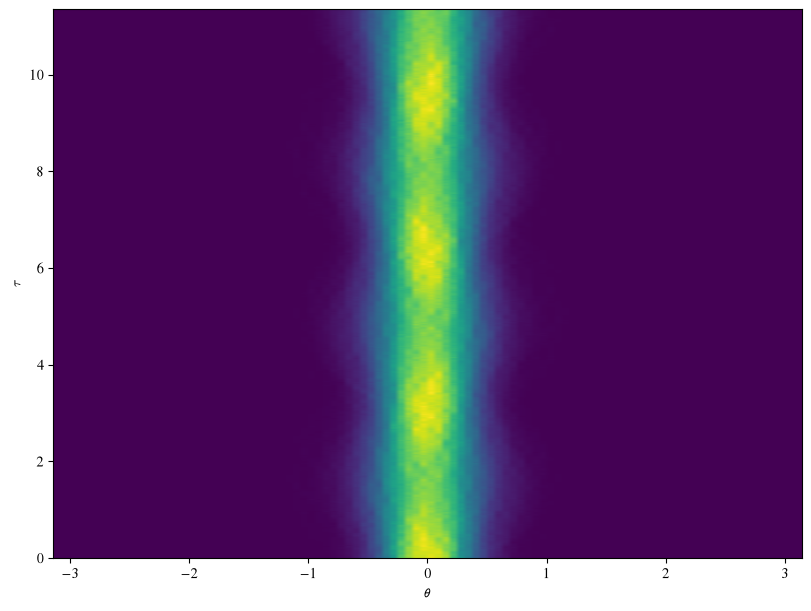

In [16]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
ax.imshow(histograms_over_time, extent=[-np.pi, np.pi, tau_grid[0], tau_grid[-1]], aspect='auto', origin='lower', cmap='viridis')

ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\tau$")


Text(0, 0.5, '$\\tau$')

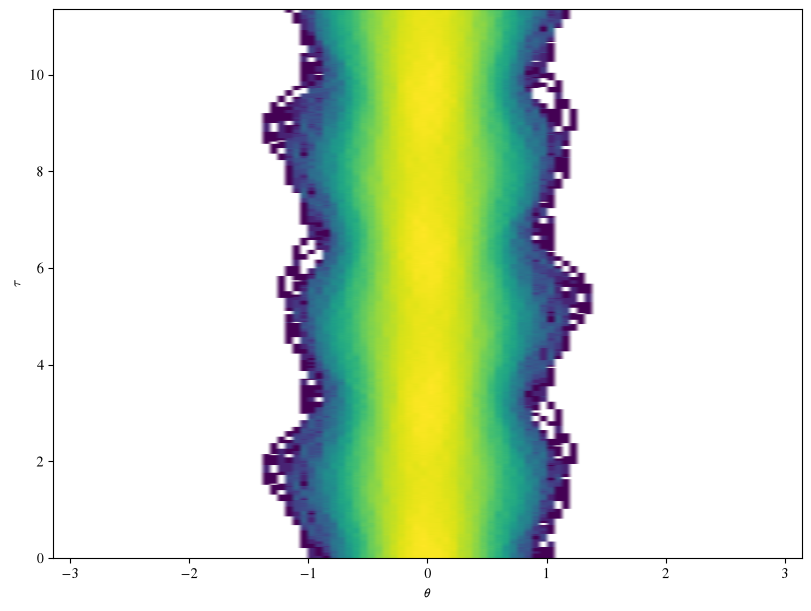

In [17]:
import matplotlib


fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
ax.imshow(histograms_over_time, extent=[-np.pi, np.pi, tau_grid[0], tau_grid[-1]], aspect='auto', origin='lower', cmap='viridis', norm=matplotlib.colors.LogNorm())

ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\tau$")
